In [ ]:
TEXT CLASSIFICATION AND SENTIMENT ANALYSIS
Improving Customer Satisfaction through Automated Review Sentiment Analysis
Overview
You are a product manager at an e-commerce company like Amazon. Your company receives thousands of customer reviews daily for various products. While ratings are available, they don’t always capture customer sentiment accurately — especially when the text and rating conflict.
Business Problem:
Your goal is to build an automated Sentiment Analysis System to classify incoming product reviews as Positive or Negative. This will help:
•	Monitor product performance in real-time
•	Identify products with sudden spikes in negative feedback
•	Improve customer satisfaction by addressing complaints faster

Dataset
•	Each row is one Amazon customer review for some product.
•	The dataset has been pre-labeled — so you already know if the review is positive or negative.
•	This is a typical sentiment analysis dataset, often used for training or testing natural language processing (NLP) models.
📊 Rows:
10,000 customer reviews
📑 Columns:
1.	label
o	Type: Text (Categorical)
o	Values: pos (positive) or neg (negative)
o	What it means: The sentiment of the review — whether the customer’s feedback is positive or negative.
2.	review
o	Type: Text
o	Values: Actual text of the review written by the customer.
o	What it means: What the customer said about the product in their own words — for example: “Excellent Soundtrack! I love it!”

Tasks
Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).
Exploratory Analysis: Word clouds, sentiment distribution, most common positive/negative words.
Model Development: Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.
Validation: Use train/test split, cross-validation, and metrics like accuracy, F1-score.





In [14]:
from wordcloud import wordcloud

In [2]:
!pip install wordcloud


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import warnings
warnings.filterwarnings('ignore')

# 1. Data Loading & Cleaning 
print("Loading dataset...")
df = pd.read_csv(r"/Users/SS/Downloads/amazonreviews.tsv", sep='\t')
df

Loading dataset...


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."
...,...,...
9995,pos,A revelation of life in small town America in ...
9996,pos,Great biography of a very interesting journali...
9997,neg,Interesting Subject; Poor Presentation: You'd ...
9998,neg,Don't buy: The box looked used and it is obvio...


In [7]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (10000, 2)
  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...


In [9]:
df = df.drop_duplicates().dropna(subset=['review']).reset_index(drop=True)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)
df['label_num'] = df['label'].map({'pos': 1, 'neg': 0})

print("\n Preprocessing completed!")


 Preprocessing completed!


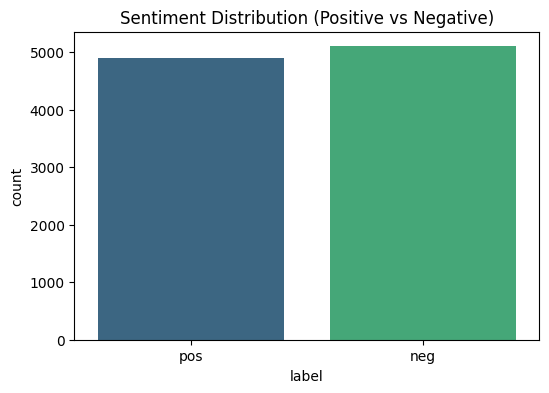

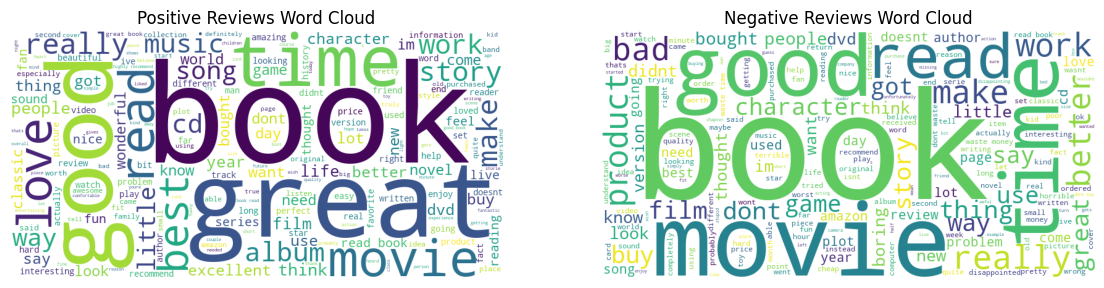

Top 10 Positive Words: [('book', 3313), ('great', 2087), ('good', 1635), ('read', 1553), ('like', 1268), ('movie', 1085), ('just', 1022), ('love', 902), ('time', 871), ('really', 827)]
Top 10 Negative Words: [('book', 3184), ('like', 1547), ('just', 1507), ('movie', 1465), ('dont', 1240), ('read', 1187), ('good', 1134), ('time', 1034), ('buy', 814), ('really', 778)]


In [10]:
# 2. Exploratory Data Analysis 

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Sentiment Distribution (Positive vs Negative)')
plt.show()

# Word Clouds
pos_text = ' '.join(df[df['label'] == 'pos']['clean_review'])
neg_text = ' '.join(df[df['label'] == 'neg']['clean_review'])

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(pos_text))
plt.title('Positive Reviews Word Cloud')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(neg_text))
plt.title('Negative Reviews Word Cloud')
plt.axis('off')
plt.show()

# Most common words
pos_words = Counter(' '.join(df[df['label']=='pos']['clean_review']).split()).most_common(10)
neg_words = Counter(' '.join(df[df['label']=='neg']['clean_review']).split()).most_common(10)

print("Top 10 Positive Words:", pos_words)
print("Top 10 Negative Words:", neg_words)

In [11]:
# 3. Feature Extraction 
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_review'])
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Model 1: TF-IDF + Logistic Regression 
print("\nTraining TF-IDF + Logistic Regression...")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("F1-Score :", f1_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Training TF-IDF + Logistic Regression...

Logistic Regression Performance:
Accuracy : 0.8495
F1-Score : 0.8455618265777322
              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1019
           1       0.85      0.84      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [12]:
# 5. Model 2: TF-IDF + SVM 
print("\nTraining TF-IDF + SVM...")
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\nSVM Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("F1-Score :", f1_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


Training TF-IDF + SVM...

SVM Performance:
Accuracy : 0.8535
F1-Score : 0.8513444951801116
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1019
           1       0.85      0.86      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000




5-Fold Cross Validation F1-Score: 0.8352 ± 0.0107


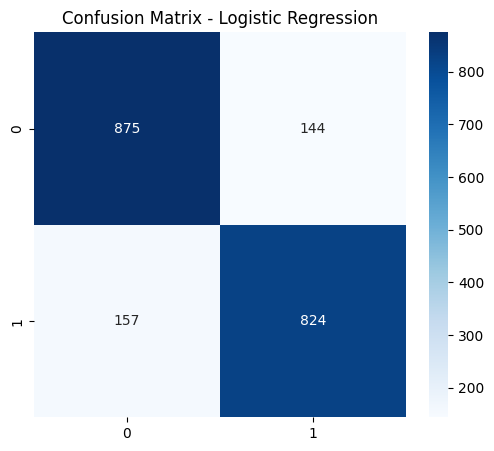

In [13]:
# 6. Cross Validation 
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='f1')
print(f"\n5-Fold Cross Validation F1-Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()